In [336]:
import numpy as np

v=np.zeros(101)
v[100]=1.0
p=0.4
theta=1e-9

In [337]:
while True:
    delta=0
    v_old=v.copy()
    for s in range(1,100):
        v[s]=0.0
        for a in range(1,min(s,100-s)+1):
            v[s]=max(v[s],p*v_old[s+a]+(1-p)*v_old[s-a])
        delta=max(delta,abs(v[s]-v_old[s]))
    if delta<theta:
        break

In [338]:
policy=np.zeros(101)
for s in range(1,100):
    bestv=-1
    besta=0
    for a in range(1,min(s,100-s)+1):
        temp=p*v[s+a]+(1-p)*v[s-a]
        if temp>bestv+1e-9:
            bestv=temp
            besta=a
    policy[s]=besta

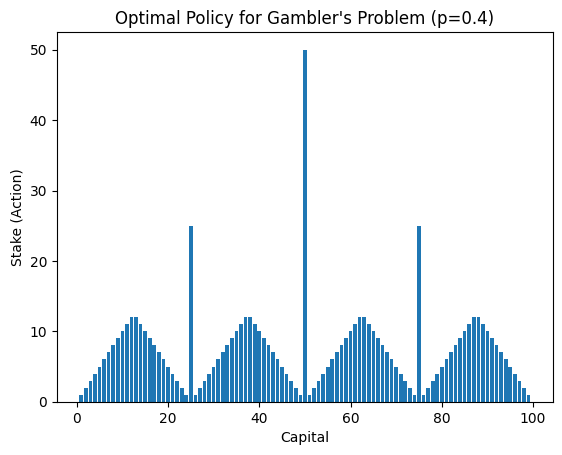

In [339]:
import matplotlib.pyplot as plt

plt.bar(range(1,100), policy[1:100])
plt.xlabel("Capital")
plt.ylabel("Stake (Action)")
plt.title("Optimal Policy for Gambler's Problem (p=0.4)")
plt.show()